# Introduction to Dual Numbers with 'dual_autodiff'

## What are Dual Numbers
**Dual numbers** are those expressed in the form: 

$$
x + \epsilon y
$$

Where:
- $x$: the **real part**.
- $y$: the **dual part** (can represent the derivative).
- $\epsilon$ is a quantity with the defining property: $\epsilon^2 = 0$

## Why Are Dual Numbers Useful?

### Automatic Differentiation
Dual numbers are used within  **forward-mode automatic differentiation**, a method for computing **exact derivatives of** functions. 
This method has has low computational overhead and can simulteously compute a functions value $f(x)$ and its derivative $f'(x)$.

For a function $f(x)$, using dual numbers, we can compute both the value of the function and its derivative simultaneously.
Consider $f(x) = x^2$:
- Input: Dual number - $x + \epsilon$
- Output: 

$$
f(x) = (x + \epsilon)^2 = x^2 + 2x\epsilon
$$

- $x^2$: Outputs real value - the functions value
- $2x$: Outputs dual value - the functions derivative

### Applications:
- **Optimization**: In algorithms like gradient descent.
- **Machine Learning**: Enabling backpropagation and training of neural networks.
- **Physics and Engineering**: For solving differential equations.


## Using dual_autodiff
### 1: Installing dual_autodiff

1. Clone the repository:
    ```bash
    git clone https://github.com/JacobTutt/dual_autodiff_package.git
    cd dual_autodiff_package
    ```

2. Install the package in editable mode:
    ```bash
    pip install .
    ```


**Note**: To be able to run this Tutorial Notbook - install required dependencies using:

1. **From cloned Repository**
    ```bash
    pip install '.[tutorial]'
    ```

In [82]:
pip show dual_autodiff

Name: dual_autodiff
Version: 1.0.1.post16
Summary: A Python package for forward-mode automatic differentiation using dual numbers.
Home-page: https://github.com/JacobTutt/dual_autodiff
Author: Jacob Tutt
Author-email: Jacob Tutt <jacobtutt@icloud.com>
License: MIT
Location: /Users/jacobtutt/Desktop/MPhil_DIS/C1/Coursework_C1/dual_autodiff_package_venvs/dual_autodiff_package_venv/lib/python3.10/site-packages
Editable project location: /Users/jacobtutt/Desktop/MPhil_DIS/C1/Coursework_C1/dual_autodiff_package
Requires: numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


### Importing the 'Dual' class

In [83]:
from dual_autodiff import Dual

### Initialising dual numbers
Example: $1 + 2\epsilon$

In [84]:
dual_number = Dual(1,2)
print(dual_number)

Dual(real=1.0, dual=2.0)


Note: Only accepts scalar inputs (int/float)

In [85]:
try:
    x = Dual(1, "two") 
except TypeError as e:
    print(e) 

'Dual part' must be a number (int or float), got str.


### Basic arithmetic operations

In [86]:
x = Dual(5,3)
y = Dual(2,1)

#### Addition: 
$(a + b\epsilon) + (c + d\epsilon) = (a + c) + (b + d)\epsilon$

Example: $(5 + 3\epsilon) + (2 + 1\epsilon) = 7 + 4\epsilon$


In [87]:
print(x+y)

Dual(real=7.0, dual=4.0)


#### Subtraction: 
$(a + b\epsilon) - (c + d\epsilon) = (a - c) + (b - d)\epsilon$

Example: $(5 + 3\epsilon) - (2 + 1\epsilon) = 3 + 2\epsilon$

In [88]:
print(x-y)

Dual(real=3.0, dual=2.0)


#### Multiplication: 
$(a + b\epsilon) \cdot (c + d\epsilon) = (a \cdot c) + (a \cdot d + b \cdot c)\epsilon$

Example: $ (5 + 3\epsilon) \cdot (2 + 1\epsilon) = (5 \cdot 2) + (5 \cdot 1 + 3 \cdot 2)\epsilon = 10 + 11\epsilon$

In [89]:
print(x*y)

Dual(real=10.0, dual=11.0)


#### Scalar Multiplication (by $k$):
$
k \cdot (a + b\epsilon) = (k \cdot a) + (k \cdot b)\epsilon $

Example:$ 2 \cdot (5 + 3\epsilon) = (2 \cdot 5) + (2 \cdot 3)\epsilon = 10 + 6\epsilon $

In [90]:
print(2*x)

Dual(real=10.0, dual=6.0)


#### Division:
$\frac{(a + b\epsilon)}{(c + d\epsilon)} = \frac{a}{c} + \frac{b \cdot c - a \cdot d}{c^2}\epsilon$

Example: $\frac{(5 + 3\epsilon)}{(2 + 1\epsilon)} = \frac{5}{2} + \frac{3 \cdot 2 - 5 \cdot 1}{2^2}\epsilon= 2.5 + 0.25\epsilon$


In [91]:
print(x/y)

Dual(real=2.5, dual=0.25)


#### Error Warning: 
- Note result of division is **undefined when real part of denominator is 0**
- Will throw ZeroDivisionError: Cannot divide by a Dual number with no real part.



In [92]:
y_error = Dual(0,1)
try:
    x/y_error
except ZeroDivisionError as e:
    print(e) 

Cannot divide by a Dual number with no real part.


#### Scalar Division (by $k$):
$\frac{(a + b\epsilon)}{k} = \frac{a}{k} + \frac{b}{k}\epsilon$

Example:
$\frac{(5 + 3\epsilon)}{2} = \frac{5}{2} + \frac{3}{2}\epsilon = 2.5 + 1.5\epsilon$

In [93]:
print(x/2)

Dual(real=2.5, dual=1.5)


#### Scalar Division (of $k$):
$\frac{k}{(a + b\epsilon)} = \frac{k}{a} - \frac{k \cdot b}{a^2}\epsilon$

Example:
$\frac{10}{(5 + 3\epsilon)} = \frac{10}{5} - \frac{10 \cdot 3}{5^2}\epsilon = 2 - 1.2\epsilon$

In [94]:
print(10/x)

Dual(real=2.0, dual=-1.2)


### More complex functions

**'dual_autodiff'** makes use of the property: 

$f(x + b\epsilon) = f(x) + f'(x) \cdot b\epsilon$

#### And currently supports the following types of functions: 
- Trigonometric (and Inverse)
- Hyperbolic
- Powers and Square Root
- Exponential and Natural Logarithms

#### Integration with pythons `math` library
- The package has been design in a way to incorporate integration with the built in python math library
- Functions can either be evaluated on Dual numbers using:
1. Using **class function**
- these can be used by default with Dual Class


    ```python
    x = Dual(2,1)
    x.sin()
    ```
2. Using **math operator**
- import maths functions created within dual_autodiff


    ```python
    from dual_autodiff import sin, cos, tan,....
    x = Dual(2,1)
    sin(x)
    ```


#### Trigonometric Functions

In [95]:
from dual_autodiff import sin, cos, tan
z = Dual(0.5,0.5)
print(f'z: {z}')
print(f'Sin(z): {sin(z)}')
print(f'Cos(z): {cos(z)}')
print(f'Tan(z): {tan(z)}')

z: Dual(real=0.5, dual=0.5)
Sin(z): Dual(real=0.479425538604203, dual=0.4387912809451864)
Cos(z): Dual(real=0.8775825618903728, dual=-0.2397127693021015)
Tan(z): Dual(real=0.5463024898437905, dual=0.6492232052047624)


#### Error Warning: 
- Note Tan is **undefined in where Cos(x) = 0**
- Will throw ValueError: The tangent function is undefined as cosine of real part equals 0

In [96]:
import math
z_error = Dual(math.pi/2,1)
try:
    tan(z_error)
except ValueError as e:
    print(e) 

Tangent undefined when cosine of real part equals 0.


#### Inverse Trignometric Functions

In [97]:
from dual_autodiff import arcsin, arccos, arctan
z = Dual(0.5,0.5)
print(f'z: {z}')
print(f'Asin(z): {arcsin(z)}')
print(f'Acos(z): {arccos(z)}')
print(f'Atan(z): {arctan(z)}')

z: Dual(real=0.5, dual=0.5)
Asin(z): Dual(real=0.5235987755982988, dual=0.5773502691896258)
Acos(z): Dual(real=1.0471975511965976, dual=-0.5773502691896258)
Atan(z): Dual(real=0.46364760900080615, dual=0.4)


#### Error Warning: 
- Note Arcsin and Arccos are **undefined ouside of domain [1,-1]**
- Will throw ValueError: Arc... are only defined for real parts in the range [-1, 1].

In [98]:
z_error = Dual(4, 0.5) 
try:
    arcsin(z_error)
except ValueError as e:
    print(e) 

Arcsine is only defined for real parts in the range [-1, 1].


#### Hyperbolic Functions

In [99]:
from dual_autodiff import sinh, cosh, tanh
z = Dual(0.5,0.5)
print(f'z: {z}')
print(f'sinh(z): {(sinh(z))}')
print(f'cosh(z): {cosh(z)}')
print(f'tanh(z): {tanh(z)}')

z: Dual(real=0.5, dual=0.5)
sinh(z): Dual(real=0.5210953054937474, dual=0.5638129826031903)
cosh(z): Dual(real=1.1276259652063807, dual=0.2605476527468737)
tanh(z): Dual(real=0.46211715726000974, dual=0.3932238664829637)


#### Exponential and Logarithim

In [100]:
from dual_autodiff import exp, log
z = Dual(0.5,0.5)
print(f'z: {z}')
print(f'exp(z): {exp(z)}')
print(f'log(z): {log(z)}')

z: Dual(real=0.5, dual=0.5)
exp(z): Dual(real=1.6487212707001282, dual=0.8243606353500641)
log(z): Dual(real=-0.6931471805599453, dual=1.0)


#### Error Warning: 
- Note logarithms are  **undefined for negetive inputs**
- Will throw ValueError: Logarithm is undefined for dual numbers with non-positive real parts.

In [101]:
z_error = Dual(-1,0.5)
try:
    log(z_error)
except ValueError as e:
    print(e) 

Logarithm is undefined for dual numbers with non-positive real parts.


#### Powers and Squareroot

In [102]:
from dual_autodiff import pow, sqrt
z = Dual(2,5)
print(f'z: {z}')
print(f'z^4: {pow(z,4)}')
print(f'z^(1/2): {sqrt(z)}')

z: Dual(real=2.0, dual=5.0)
z^4: Dual(real=16.0, dual=160.0)
z^(1/2): Dual(real=1.4142135623730951, dual=1.7677669529663687)


#### Error Warning: 
- Squareroot of 'Dual class' does not support imaginary numbers
- **Undefined for negetive inputs**
- Will throw ValueError: Square root is undefined when real parts of dual number are negetive.

In [103]:
z_error = Dual(-1,0.5)
try:
    sqrt(z_error)
except ValueError as e:
    print(e) 

Square root is undefined when real parts of dual number are negetive.


### Automatic Differentiation

**`dual_autodiff`** offers an **automatic differentiation** feature: `auto_diff`

#### About `auto_diff`

- **Takes**:
  - A **real function** $f(x)$
  - A **value** $x_0$ at which the derivative is evaluated.
  
- **Returns**:
  - Tuple containing
    - The value of $f'(x_0)$ at the specified point.
    - The derivative $f'(x_0)$ at the specified point.
  
- **Note**:
  - `auto_diff` has been designed to incorporate a wide range of mathemematical features as function inputs but some may not be currently supported and additional verification may be required.


### Example 1 (Simple)

**Function:**

$f(x) = x^3 + 3x^2 - 4$

**Derivative (Analytical):**

$f'(x) = 3x^2 + 6x$

**Evaluate at $ x = 2 $:**

$f'(2) = 3(2)^2 + 6(2) = 12 + 12 = 24$

**Derivative (auto_diff):**

In [104]:
from dual_autodiff import auto_diff

# Define the real function that can passed to auto_diff
def f_simple(x):
    return x**3 + 3 * x**2 - 4

# Compute the derivative at x = 2
deriv_x_simple = auto_diff(f_simple, 2)

print(f"The value of the function: {deriv_x_simple[0]:.1f}")
print(f"The value of the derivative: {deriv_x_simple[1]:.1f}")

The value of the function: 16.0
The value of the derivative: 24.0


### Example 2 (More Complex)

**Function:**
$f(x) = \log(\sin(x)) + x^2 \cos(x)$

**Derivative (Analytical):**

$f'(x) = \frac{\cos(x)}{\sin(x)} + 2x \cos(x) - x^2 \sin(x)$

**Evaluate at $x = 1.5$:**

Substitute \( x = 1.5 \) into \( f'(x) \):

$f'(1.5) = \frac{\cos(1.5)}{\sin(1.5)} + 2(1.5)\cos(1.5) - (1.5)^2 \sin(1.5)$
$f'(1.5) \approx -1.9612$

**Derivative (auto_diff):**

In [105]:
# Define the real function that can passed to auto_diff
def f_complex(x):
    return log(sin(x)) + x**2 * cos(x)

# Compute the derivative at x = 1.5
deriv_x_complex = auto_diff(f_complex, 1.5)
print(f"The value of the function: {deriv_x_complex[0]:.4f}")
print(f"The value of the derivative: {deriv_x_complex[1]:.4f}")

The value of the function: 0.1567
The value of the derivative: -1.9612


## Numpy Integration in V 1.1.0

The recent release of `dual_autodiff` provides extensive integration with `numpy` arrays

Below are examples of how the user can seamlessly work with arrays of dual numbers.

#### 1. **Enhanced Mathematical Functions**: 
- All mathematical functions such as `sin`, `cos`, `tan`, `exp`, `log`, `sqrt`, and more are now fully compatible with `numpy` arrays of dual numbers .

In [120]:
import numpy as np
x = np.array([Dual(1,2), Dual(0.1,0.4), Dual(3,4)])
y = np.array([Dual(3, 4), Dual(0.5, 0.2), Dual(0.6, 0.3)])

In [122]:
sin(x)
# Ie [sin(Dual(1,2)), sin(Dual(0.1,0.4)), sin(Dual(3,4))]

array([Dual(real=0.8414709848078965, dual=1.0806046117362795),
       Dual(real=0.09983341664682815, dual=0.39800166611121035),
       Dual(real=0.1411200080598672, dual=-3.9599699864017817)],
      dtype=object)

In [121]:
tanh(y)
# [tanh(Dual(3,4)), tanh(Dual(0.5,0.2)), tanh(Dual(0.6,0.3))]

array([Dual(real=0.9950547536867305, dual=0.039464148661760845),
       Dual(real=0.46211715726000974, dual=0.1572895465931855),
       Dual(real=0.5370495669980353, dual=0.21347332877616684)],
      dtype=object)

In [ ]:
pow(x, 2)
# [pow(Dual(1,2), 2), pow(Dual(0.1,0.4), 2), pow(Dual(3,4), 2)]

array([Dual(real=1.0, dual=4.0), Dual(real=4.0, dual=12.0),
       Dual(real=9.0, dual=24.0)], dtype=object)

#### This includes `comparsion operators`
- Comparisions are made element wise

In [123]:
x == x
# [True, True, True]

array([ True,  True,  True])

In [125]:
x <= y
# [True, True, False]

array([ True,  True, False])

#### 2. **Advanced Auto-differentiation Functions**: 
- Extended `auto_diff` to be fully compatible with `numpy` arrays, enabling automatic differentiation over arrays of dual numbers.

In [132]:
# Define the real function that can passed to auto_diff
def f_complex(x):
    return log(sin(x)) + x**2 * cos(x)

# Numpy array of values that you wish to evaulate the function at
x = np.array([0.5, 1, 1.5])

# Compute the value and derivative at x = 0.5, 1, 1.5
deriv_x_complex = auto_diff(f_complex, x)

print(f"The values of the function: {deriv_x_complex[0]}")
print(f"The values of the derivative: {deriv_x_complex[1]}")

The values of the function: [-0.51577105  0.36769856  0.15665055]
The values of the derivative: [ 2.5882139   0.88122624 -1.96123727]


#### 3. **Multi-Function Differentiation**: 
- Introduced the `multi_auto_diff` function, allowing users to evaluate multiple functions and their derivatives at once, and even over a range (array) of points.

In [150]:
from dual_autodiff import multi_auto_diff

# Define a list of functions that can passed to multi_audo_diff
funcs = [
    lambda x: x**2 + x,
    lambda x: sin(x),
    lambda x: log(x)
]
    
# Numpy array of values that you wish to evaulate each of the functions at
x = np.array([1, 2, 3])

# Compute the value and derivative at x = 1, 2, 3
multi_func_eval = multi_auto_diff(funcs, x)


print(f"Function 1: x^2 + x")
print(f"The values of the function: {multi_func_eval[0][0]}")
print(f"The values of the derivative: {multi_func_eval[0][1]}")

print(f"\nFunction 2: sin(x)")
print(f"The values of the function: {multi_func_eval[1][0]}")
print(f"The values of the derivative: {multi_func_eval[1][1]}")

print(f"\nFunction 3: log(x)")
print(f"The values of the function: {multi_func_eval[2][0]}")
print(f"The values of the derivative: {multi_func_eval[2][1]}")

Function 1: x^2 + x
The values of the function: [ 2.  6. 12.]
The values of the derivative: [3. 5. 7.]

Function 2: sin(x)
The values of the function: [0.84147098 0.90929743 0.14112001]
The values of the derivative: [ 0.54030231 -0.41614684 -0.9899925 ]

Function 3: log(x)
The values of the function: [0.         0.69314718 1.09861229]
The values of the derivative: [1.         0.5        0.33333333]


#### **Visulisation of Results**: 
- In the visulisation of the results the previous examples is used with the `multi_auto_diff` however the same results can be produced one function at a time using `auto_diff`

In [171]:
# The values we will evaluate the functions over
x_vals = np.linspace(0.01, np.pi, 100)

# Define the functions we will evaluate
def f1(x): 
    return x**2 + x

def f2(x):
    return sin(x)

def f3(x):
    return log(x)

funcs = [f1, f2, f3]

# Use multi_auto_diff to evaluate the functions and their derivatives
multi_func_eval = multi_auto_diff(funcs, x_vals)


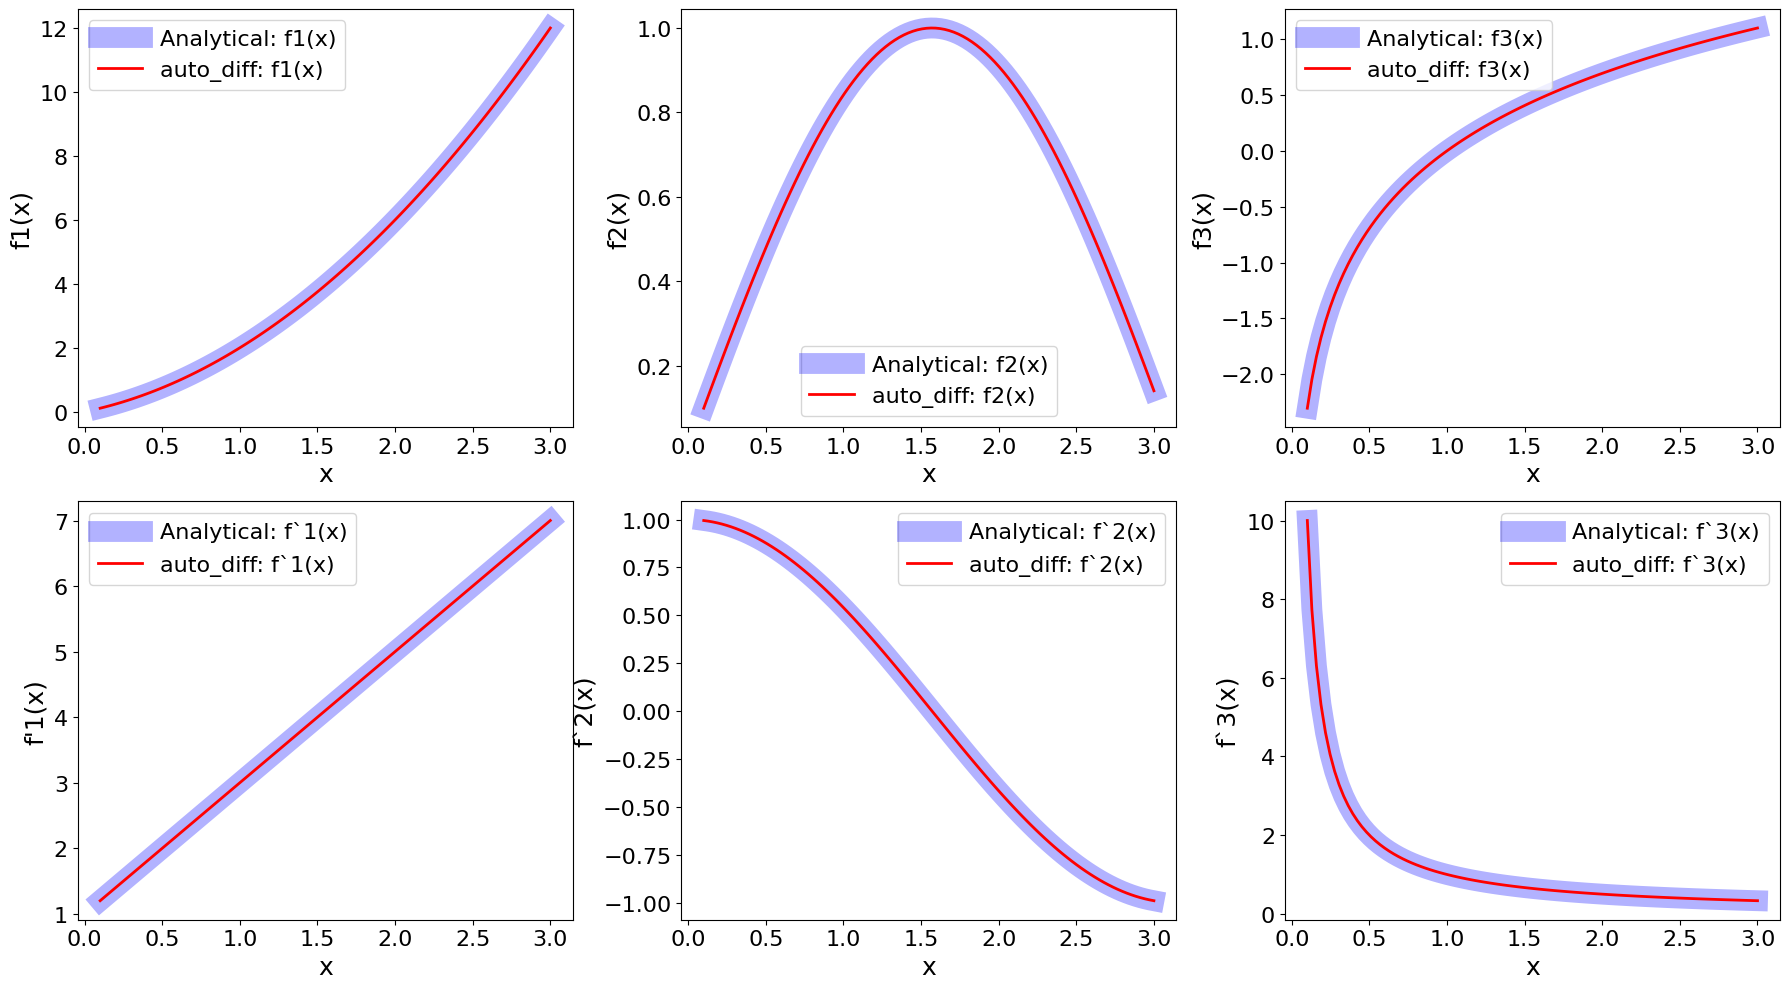

In [177]:
import numpy as np
import matplotlib.pyplot as plt

# Define functions
def f1(x):
    return x**2 + x

def f2(x):
    return sin(x)

def f3(x):
    return log(x)

# Define derivatives for the functions for verification for the plot
def f1_dev(x):
    return 2*x + 1

def f2_dev(x):
    return cos(x)

def f3_dev(x):
    return 1/x

# Create numpy array
x_vals = np.linspace(0.1, 3, 100)  # Avoid zero to prevent log(sin(x)) from being undefined
x_points = np.array([1, 2, 3])
funcs = [f1, f2, f3]
multi_func_eval = [auto_diff(f, x_vals) for f in funcs]

# Verify the results in a plot
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Plot analytical value and auto_diff value for f1
axs[0,0].plot(x_vals, f1(x_vals), color='blue', alpha=0.3, lw=15, label="Analytical: f1(x)")
axs[0,0].plot(x_vals, multi_func_eval[0][0], color='red', lw=2, label="auto_diff: f1(x)")
axs[0,0].set_xlabel("x", fontsize=18)
axs[0,0].set_ylabel("f1(x)", fontsize=18)
axs[0,0].tick_params(axis='both', which='major', labelsize=16)
axs[0,0].legend(fontsize=16)

# Plot analytical derivative and auto_diff derivative for f1
axs[1,0].plot(x_vals, f1_dev(x_vals), color='blue', alpha=0.3, lw=15, label="Analytical: f`1(x)")
axs[1,0].plot(x_vals, multi_func_eval[0][1], color='red', lw=2, label="auto_diff: f`1(x)")
axs[1,0].set_xlabel("x", fontsize=18)
axs[1,0].set_ylabel("f'1(x)", fontsize=18)
axs[1,0].tick_params(axis='both', which='major', labelsize=16)
axs[1,0].legend(fontsize=16)

# Plot analytical value and auto_diff value for f2
axs[0,1].plot(x_vals, f2(x_vals), color='blue', alpha=0.3, lw=15, label="Analytical: f2(x)")
axs[0,1].plot(x_vals, multi_func_eval[1][0], color='red', lw=2, label="auto_diff: f2(x)")
axs[0,1].set_xlabel("x", fontsize=18)
axs[0,1].set_ylabel("f2(x)", fontsize=18)
axs[0,1].tick_params(axis='both', which='major', labelsize=16)
axs[0,1].legend(fontsize=16)

# Plot analytical derivative and auto_diff derivative for f2
axs[1,1].plot(x_vals, f2_dev(x_vals), color='blue', alpha=0.3, lw=15, label="Analytical: f`2(x)")
axs[1,1].plot(x_vals, multi_func_eval[1][1], color='red', lw=2, label="auto_diff: f`2(x)")
axs[1,1].set_xlabel("x", fontsize=18)
axs[1,1].set_ylabel("f`2(x)", fontsize=18)
axs[1,1].tick_params(axis='both', which='major', labelsize=16)
axs[1,1].legend(fontsize=16)

# Plot analytical value and auto_diff value for f3
axs[0,2].plot(x_vals, f3(x_vals), color='blue', alpha=0.3, lw=15, label="Analytical: f3(x)")
axs[0,2].plot(x_vals, multi_func_eval[2][0], color='red', lw=2, label="auto_diff: f3(x)")
axs[0,2].set_xlabel("x", fontsize=18)
axs[0,2].set_ylabel("f3(x)", fontsize=18)
axs[0,2].tick_params(axis='both', which='major', labelsize=16)
axs[0,2].legend(fontsize=16)

# Plot analytical derivative and auto_diff derivative for f3
axs[1,2].plot(x_vals, f3_dev(x_vals), color='blue', alpha=0.3, lw=15, label="Analytical: f`3(x)")
axs[1,2].plot(x_vals, multi_func_eval[2][1], color='red', lw=2, label="auto_diff: f`3(x)")
axs[1,2].set_xlabel("x", fontsize=18)
axs[1,2].set_ylabel("f`3(x)", fontsize=18)
axs[1,2].tick_params(axis='both', which='major', labelsize=16)
axs[1,2].legend(fontsize=16)

plt.tight_layout()
plt.show()

### Cythonised version of package

`dual_autodiff` offers an **cythonized** version: `dual_autodiff_x`

- The **Cython** version significantly enhances computational efficiency by converting the original Python script into **C**, which is then **compiled into machine** code at build time. 

- In contrast, Python is an **interpreted language**, meaning the code is compiled during runtime, which has significantly more overhead and results in **slower run time**.




In [106]:
import time
import tracemalloc
from dual_autodiff_x import auto_diff as auto_diff_x
from dual_autodiff_x import Dual as Dual_x
from dual_autodiff_x import sin as sin_x, cos as cos_x, log as log_x

# Define the real function that can passed to auto_diff and auto_diff_x
def f_complex(x):
    return log(sin(x)) + x**2 * cos(x)

def f_complex_x(x):
    return log_x(sin_x(x)) + x**2 * cos_x(x)

# Initialize variables to store the total time and memory
total_python_duration = 0
total_cython_duration = 0
total_python_memory = 0
total_cython_memory = 0

# Run the test 100 times
iterations = 100000
for i in range(iterations):
    # Compute the derivative at x = 1.5 using Python version
    tracemalloc.start()
    start_time = time.time()
    deriv_x_complex = auto_diff(f_complex, 1.5)
    python_duration = time.time() - start_time
    python_memory = tracemalloc.get_traced_memory()
    tracemalloc.reset_peak()

    # Compute the derivative at x = 1.5 using Cython version
    start_time = time.time()
    deriv_x_complex_x = auto_diff_x(f_complex_x, 1.5)
    cython_duration = time.time() - start_time
    cython_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Accumulate the results
    total_python_duration += python_duration
    total_cython_duration += cython_duration
    total_python_memory += python_memory[1]
    total_cython_memory += cython_memory[1]

# Compute the averages
average_python_duration = total_python_duration / iterations
average_cython_duration = total_cython_duration / iterations
average_python_memory = total_python_memory / iterations / 1024  # Convert to KB
average_cython_memory = total_cython_memory / iterations / 1024  # Convert to KB

# Print the averages
print(f"Average Python version time: {average_python_duration} seconds")
print(f"Average Cython version time: {average_cython_duration} seconds\n")

print(f"Average Python version memory usage: {average_python_memory:.2f} KB")
print(f"Average Cython version memory usage: {average_cython_memory:.2f} KB \n")

print(f"Percentage change run time: {(average_cython_duration - average_python_duration)*100/average_python_duration:.4f} - Decrease")
print(f"Percentage change memory usage: {(average_cython_memory - average_python_memory)*100/average_python_memory:.4f} - Increase")



Average Python version time: 1.683248519897461e-05 seconds
Average Cython version time: 1.2163898944854736e-05 seconds

Average Python version memory usage: 0.52 KB
Average Cython version memory usage: 0.57 KB 

Percentage change run time: -27.7356 - Decrease
Percentage change memory usage: 9.6997 - Increase
